## Neural Network Approach for Seasonal Items Forecasting of a Retail Store
## All models in one notebook + Results and Comparison

## Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
import seaborn as sns
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from pylab import rcParams
import itertools
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import sys

from statsmodels.tools.eval_measures import rmse
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from keras.layers import Bidirectional
from keras.layers import LSTM
import warnings

from keras.layers import RepeatVector
from keras.layers import Flatten
from keras.layers import TimeDistributed
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from sklearn.metrics import mean_squared_error

import os

from datetime import datetime
from pandas import DataFrame
from pandas import concat
from pandas import Series

## Load Dataset

In [6]:
data= pd.read_excel('MRP_data.xls')

## Edit columns names

In [7]:
# Lower case column names
data.columns = map(str.lower, data.columns)

#Replace spaces with '_'
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("-", "_")
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## Separate dataframe of each category

In [8]:
furniture=data.loc[data['category'] == 'Furniture']

technology=data.loc[data['category'] == 'Technology']
office=data.loc[data['category'] == 'Office Supplies']

## Aggregating sales data by date

In [9]:
furniture= furniture.groupby('order_date')['sales'].sum().reset_index()

technology= technology.groupby('order_date')['sales'].sum().reset_index()
office= office.groupby('order_date')['sales'].sum().reset_index()

In [10]:
#Set index
furniture = furniture.set_index('order_date')

technology = technology.set_index('order_date')
office = office.set_index('order_date')

In [11]:
#furniture['sales']

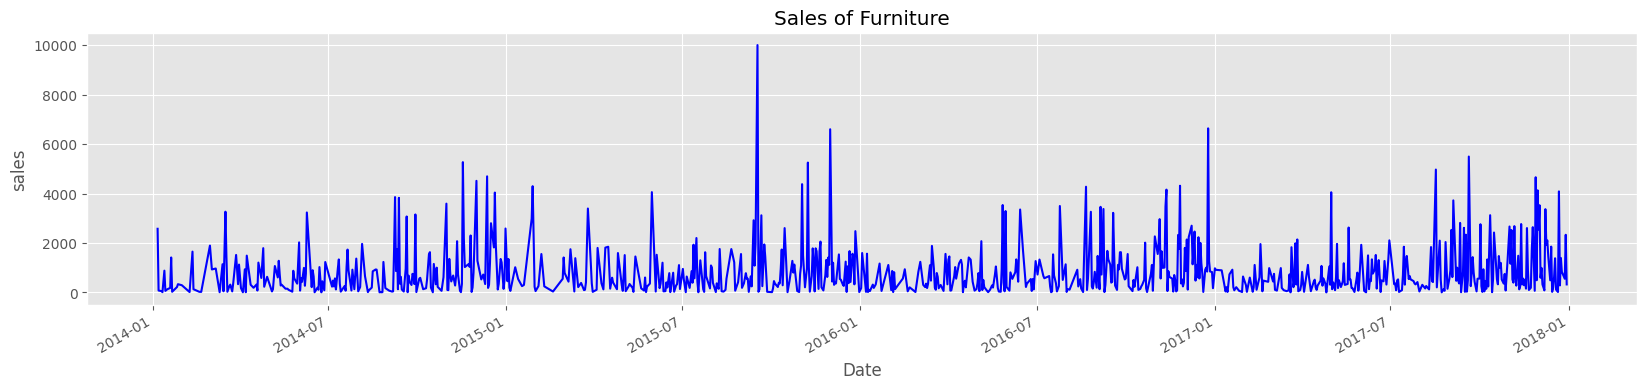

In [12]:
ax= furniture['sales'].plot(color='blue',figsize=(20,4))
ax.set_xlabel("Date")
ax.set_ylabel('sales')
ax.set_title("Sales of Furniture")
plt.show()

In [13]:
#Resampling the data on monthly frequency
# Using averages daily sales value - set start of the month as index
df = furniture['sales'].resample('MS').mean()

#avg_technology_sales = technology_sales['sales'].resample('MS').mean()
#avg_office_sales = office_sales['sales'].resample('MS').mean()

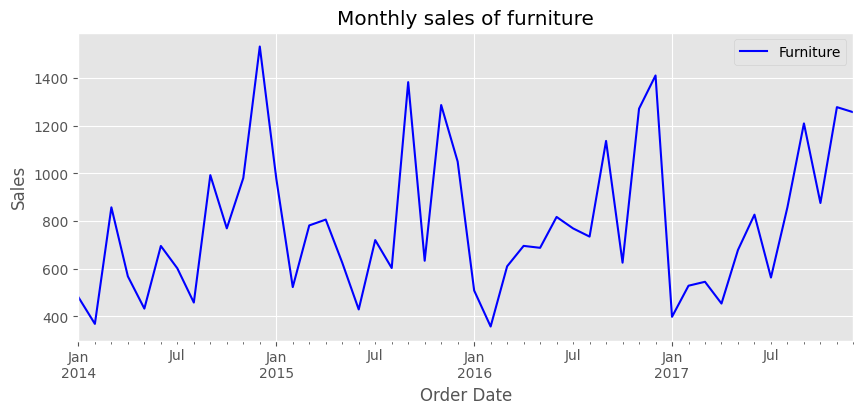

In [14]:
df.plot(figsize=(10, 4),color='blue',label = 'Furniture')
plt.xlabel("Order Date")
plt.ylabel('Sales')
plt.title("Monthly sales of furniture")
plt.legend()
plt.show()

## Seasonal decomposition:

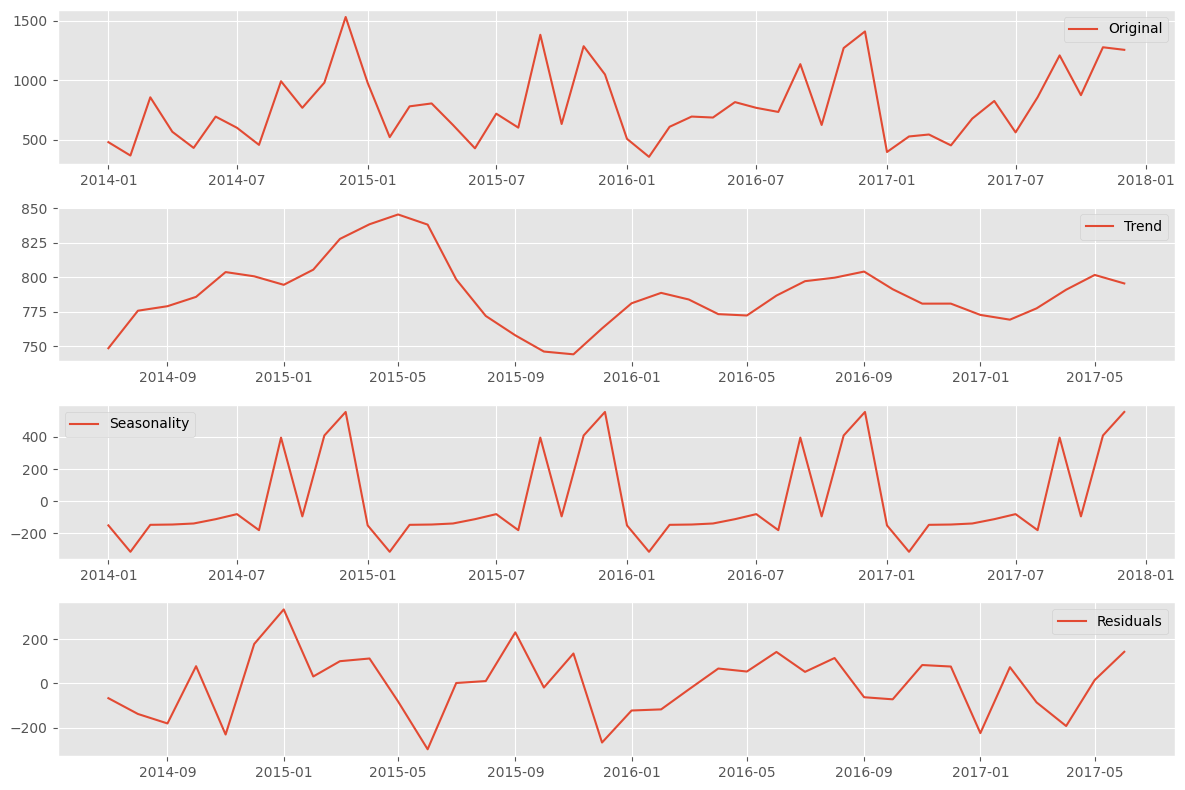

In [16]:
#Furniture time-series decomposition
decomposition = seasonal_decompose(df, period=12)
rcParams['figure.figsize'] = 12, 8

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(df, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

In [17]:
def test_stationarity(timeseries):
    rcParams['figure.figsize'] = 10, 6
    rolmean = timeseries.rolling(12).mean() #allows you to calculate moving avg
    rolstd = timeseries.rolling(12).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    print('p-value=', dftest[1])

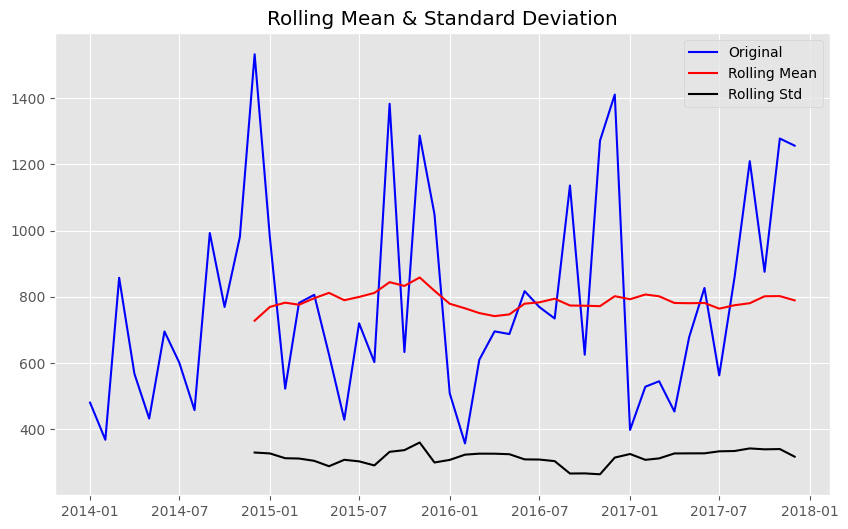

Results of Dickey-Fuller Test:
p-value= 9.1687566556655e-06


In [18]:
#check to see if the time-series is stationary or non-stationary
test_stationarity(df)
#p-value= 9.168756655665942e-06

### Train and test split

In [19]:
X = df
train_size = int(len(X) * 0.75)
trainset, testset= X[0:train_size], X[train_size:]

### Measure of prediction accuracy

In [20]:
def performance(y_true, y_pred):
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    performance_data= {'MSE':round(mse, 2),
                      'RMSE':round(np.sqrt(mse), 2),
                       'MAPE':round(mape, 2)
                      }
    return performance_data

def performance2(y_true, y_pred):
    #y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return( print(' The MSE of forecasts is {}'.format(round(mse, 2))+
                  '\n The RMSE of forecasts is {}'.format(round(np.sqrt(mse), 2))+
                  '\n The MAPE of forecasts is {}'.format(round(mape, 2))))

## ARIMA model

### Grid Search

In [22]:
import warnings
from pandas import Series
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error

# evaluate an ARIMA model
def evaluate_arima_model(X, arima_order):
    # prepare training dataset
    train_size = int(len(X) * 0.75)
    train, test = X[0:train_size], X[train_size:]
    history = [x for x in train]
    # make predictions
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit(disp=0)
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test[t])
    # calculate out of sample error
    error = mean_squared_error(test, predictions)
    return error

# evaluate the combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    mse = evaluate_arima_model(dataset, order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print('ARIMA%s MSE=%.3f' % (order,mse))
                except:
                    continue
    print('Best ARIMA%s MSE=%.3f' % (best_cfg, best_score))

In [23]:
# evaluate parameters
p_values = [0, 1, 2, 4,6]
d_values = range(0, 2)
q_values = range(0, 2)
warnings.filterwarnings("ignore")
evaluate_models(df.values, p_values, d_values, q_values)

Best ARIMANone MSE=inf


In [26]:
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(trainset, order = (6,0,0))
model_arima_fit = model_arima.fit()
arima_predict = model_arima_fit.predict(start=pd.to_datetime('2017-01-01'), end=pd.to_datetime('2017-12-01')
                                           ,dynamic=False)

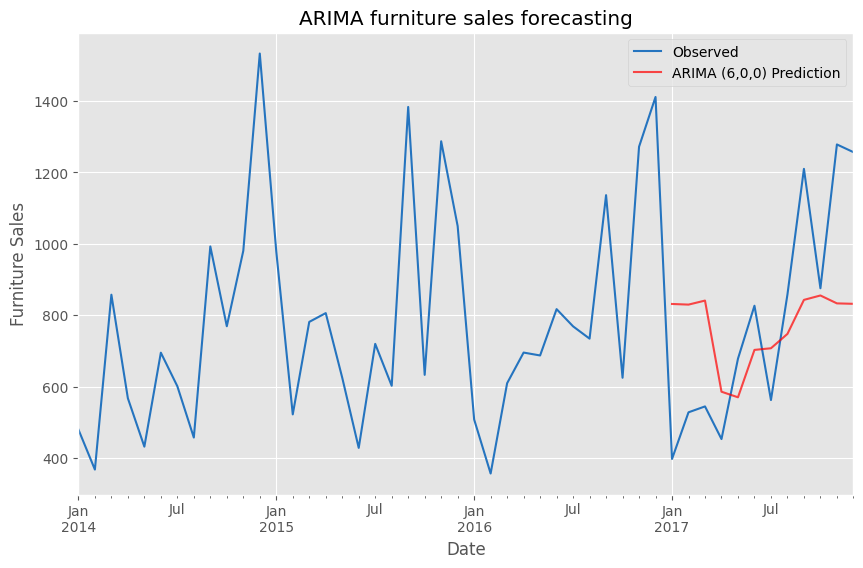

In [27]:
# One step ahead forecast
#observed plot
ax = df.plot(label='Observed',color='#2574BF')
#predicted plot
rcParams['figure.figsize'] = 14, 7
arima_predict.plot(ax=ax, label='ARIMA (6,0,0) Prediction', alpha= 0.7, color='red')
plt.title('ARIMA furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [28]:
arima_results= performance(df[-12:],arima_predict)
arima_results

{'MSE': 79779.2, 'RMSE': 282.45, 'MAPE': 35.04}

## ACF plot

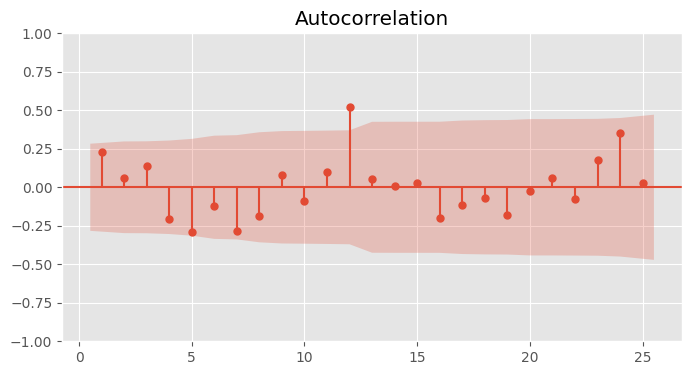

In [30]:
from statsmodels.graphics.tsaplots import plot_acf
fig,ax = plt.subplots(1,1,figsize=(8,4))
plot_acf(df,ax=ax,zero=False,lags=25)
plt.show()

#From the peaks we can see that the frequency is 12

## Seasonal ARIMA model

### Grid search method 1 - using auto-ARIMA that reported back the best AIC value.

In [33]:
## Find optimal order
import pmdarima as pm
model_1 = pm.auto_arima(trainset,seasonal=True, m=12,d=0, D=1, max_p=2, max_q=2,
                       trace=True,error_action='ignore',suppress_warnings=True)

# Print model summary
print(model_1.summary())

#best model is Fit ARIMA: order=(0, 0, 0) seasonal_order=(1, 1, 0, 12); AIC=329.940,

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=3.56 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=338.682, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=330.948, Time=0.74 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=337.169, Time=0.06 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=340.006, Time=0.11 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=inf, Time=2.08 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=333.147, Time=1.11 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=3.06 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=329.174, Time=0.53 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=inf, Time=2.78 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=331.153, Time=2.12 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.06 sec

### Fitting the model

In [34]:
#fitting model
sarima_model_1 = sm.tsa.statespace.SARIMAX(trainset,
                                order=(0, 0, 0),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
sarima_fit_1 = sarima_model_1.fit()
print(sarima_fit_1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6292      0.176     -3.570      0.000      -0.975      -0.284
sigma2       2.25e+04   1.57e+04      1.429      0.153   -8356.220    5.34e+04


### Validating forecasts

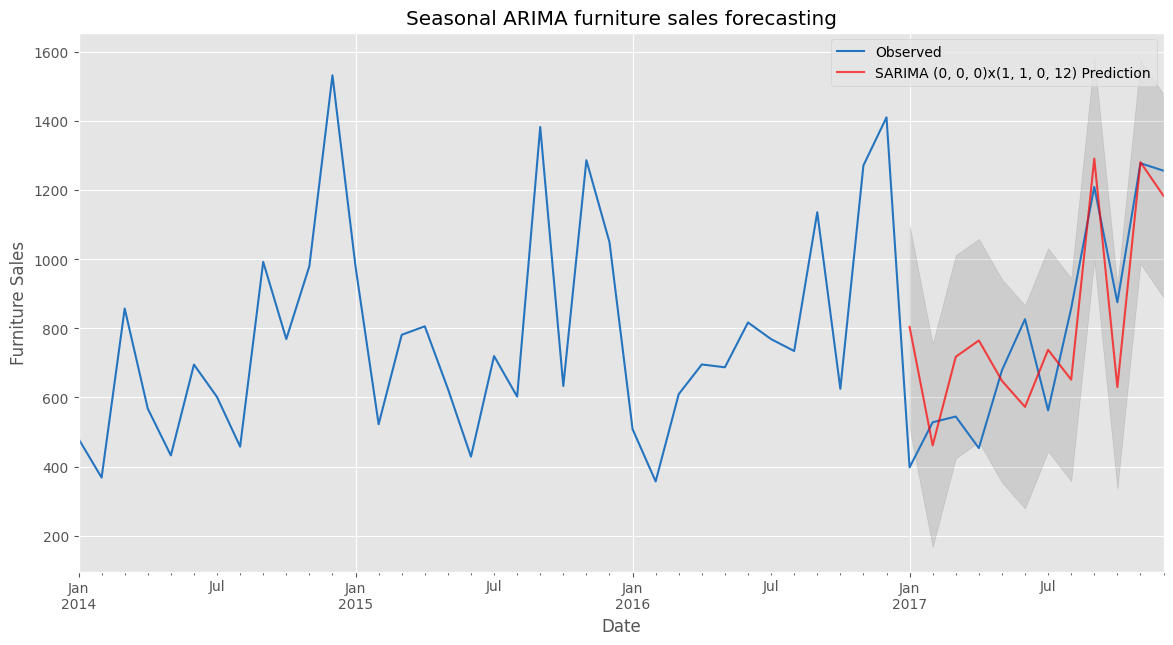

In [37]:
# One step ahead forecast
sarima_predict_1 = sarima_fit_1.get_prediction(start=pd.to_datetime('2017-01-01'), end=pd.to_datetime('2017-12-01')
                                           ,dynamic=False)
sarima_predict_conf_1 = sarima_predict_1.conf_int()
#observed plot
ax = df.plot(label='Observed',color='#2574BF')
#predicted plot
rcParams['figure.figsize'] = 14, 7
sarima_predict_1.predicted_mean.plot(ax=ax, label='SARIMA (0, 0, 0)x(1, 1, 0, 12) Prediction', alpha= 0.7, color='red')
ax.fill_between(sarima_predict_conf_1.index,
                #lower sales
                sarima_predict_conf_1.iloc[:, 0],
                #upper sales
                sarima_predict_conf_1.iloc[:, 1], color='k', alpha=0.1)
plt.title('Seasonal ARIMA furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()


In [38]:
sarima_results=performance(df[-12:],sarima_predict_1.predicted_mean)
sarima_results

{'MSE': 42305.37, 'RMSE': 205.68, 'MAPE': 28.89}

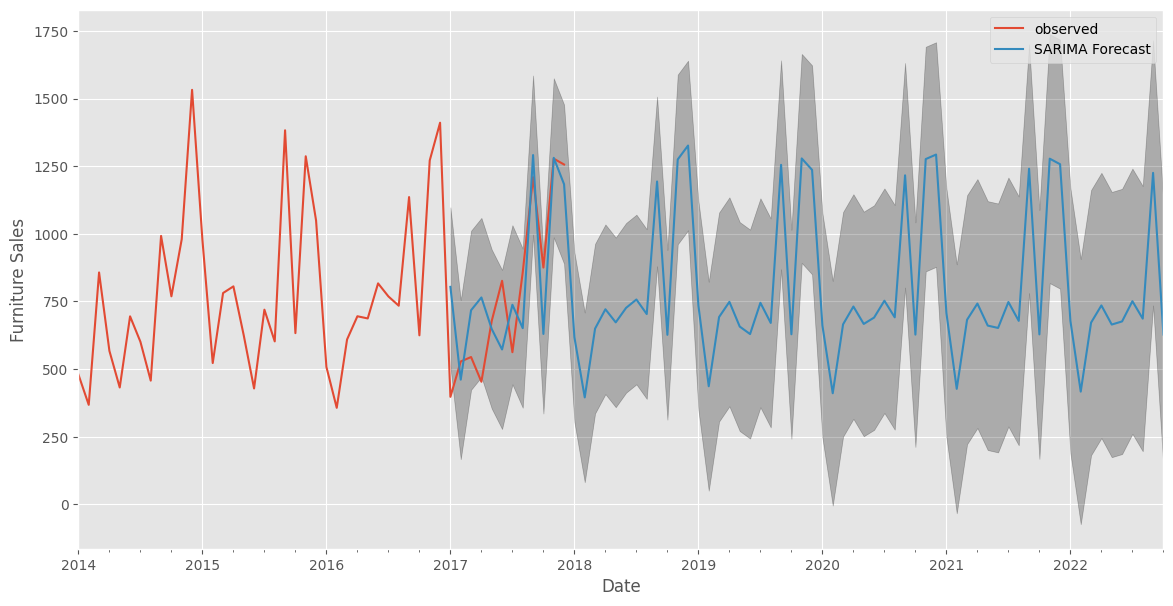

In [39]:
furthur_predict_1 = sarima_fit_1.get_forecast(steps=70)
furthur_conf_1 = furthur_predict_1.conf_int()
ax = df.plot(label='observed', figsize=(14, 7))
furthur_predict_1.predicted_mean.plot(ax=ax, label='SARIMA Forecast')
ax.fill_between(furthur_conf_1.index,
                furthur_conf_1.iloc[:, 0],
                furthur_conf_1.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

### Grid Search meethod 2 - Develop a Grid Search Framework

In [40]:
# Define the p, d and q parameters to take a value between 0 and 2
p = d = q = range(0, 2)

# Generate different combinations of p, d and q
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
print('Examples of parameter combinations for Seasonal ARIMA')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [41]:
#method 2
warnings.filterwarnings("ignore")
lowest_aic = sys.maxsize
lowest = ''

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(trainset,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit()

            print('SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))

            if lowest_aic >  results.aic:
                lowest = 'SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic)
                lowest_aic = results.aic
        except:
            continue

print ("The lowes AIC belongs to "+lowest)

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:573.2736548047211
SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:363.64804539895664
SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:320.39031701091477
SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:145.13133504245582
SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:339.13659906594717
SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:319.05810973857683
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:158.31115188193314
SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:146.42796771587655
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:535.9560974912333
SARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:338.86219019743174
SARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:308.9827688113516
SARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:130.25791565352958
SARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:340.55729582952995
SARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:307.94590618893284
SARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:158.06483656134904
SARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:134.4343024789221
SARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:501.6523533373235
SARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AI

### Fitting the model

In [42]:
#fitting model
sarima_model_2 = sm.tsa.statespace.SARIMAX(trainset,
                                order=(1, 1, 0),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
sarima_fit_2 = sarima_model_2.fit()
print(sarima_fit_2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1918      0.371     -0.517      0.606      -0.920       0.536
ar.S.L12      -0.4818      0.165     -2.922      0.003      -0.805      -0.159
sigma2      2.266e+04    1.8e+04      1.259      0.208   -1.26e+04    5.79e+04


### Validating forecasts

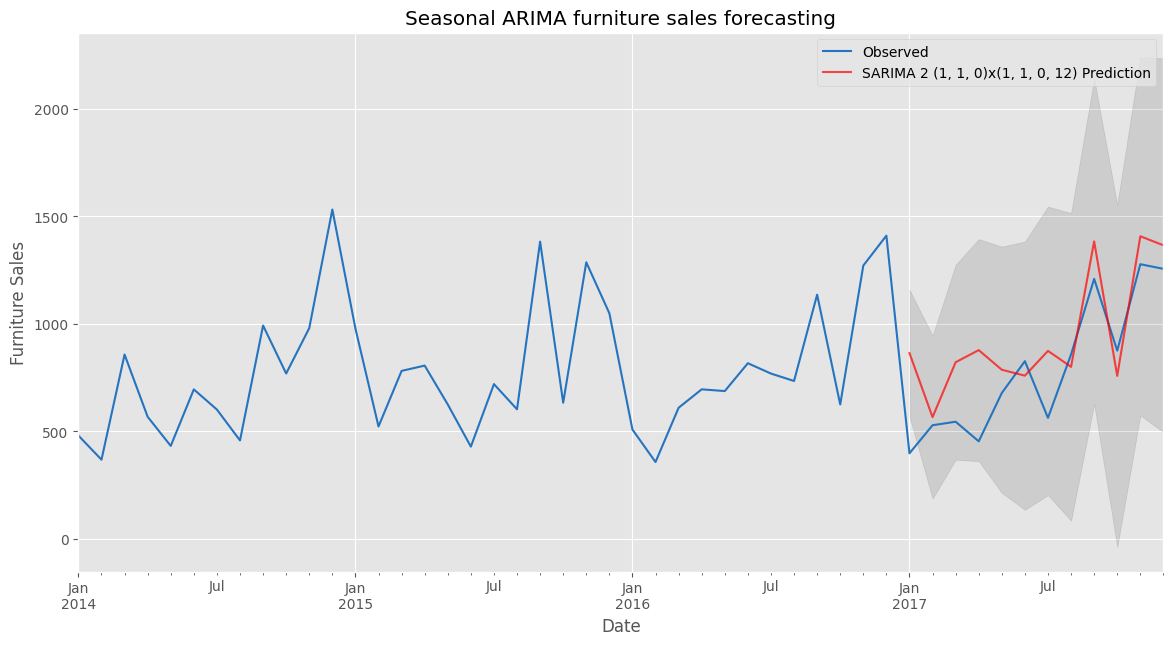

In [43]:
# One step ahead forecast
sarima_predict_2 = sarima_fit_2.get_prediction(start=pd.to_datetime('2017-01-01'), end=pd.to_datetime('2017-12-01')
                                           ,dynamic=False)
sarima_predict_conf_2 = sarima_predict_2.conf_int()
#observed plot
ax = df.plot(label='Observed',color='#2574BF')
#predicted plot
rcParams['figure.figsize'] = 14, 7
sarima_predict_2.predicted_mean.plot(ax=ax, label='SARIMA 2 (1, 1, 0)x(1, 1, 0, 12) Prediction', alpha= 0.7, color='red')
ax.fill_between(sarima_predict_conf_2.index,
                #lower sales
                sarima_predict_conf_2.iloc[:, 0],
                #upper sales
                sarima_predict_conf_2.iloc[:, 1], color='k', alpha=0.1)
plt.title('Seasonal ARIMA furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()


In [44]:
sarima_results2=performance(df[-12:],sarima_predict_2.predicted_mean)
sarima_results2

{'MSE': 55497.86, 'RMSE': 235.58, 'MAPE': 33.5}

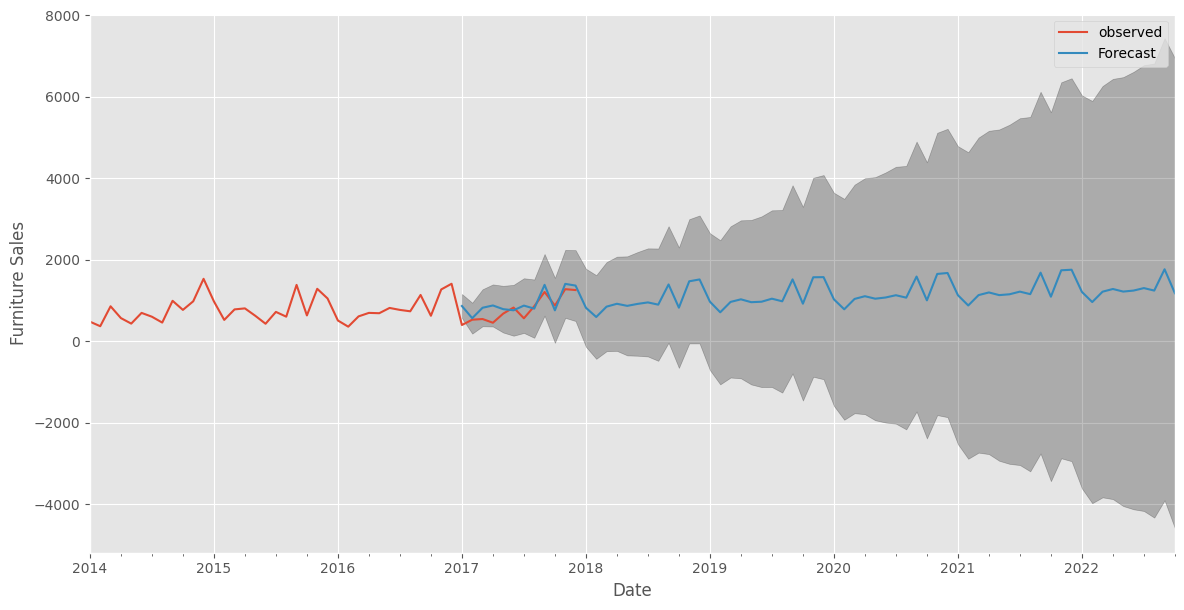

In [45]:
furthur_predict_2 = sarima_fit_2.get_forecast(steps=70)
furthur_conf_2 = furthur_predict_2.conf_int()
ax = df.plot(label='observed', figsize=(14, 7))
furthur_predict_2.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(furthur_conf_2.index,
                furthur_conf_2.iloc[:, 0],
                furthur_conf_2.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

### Comparison

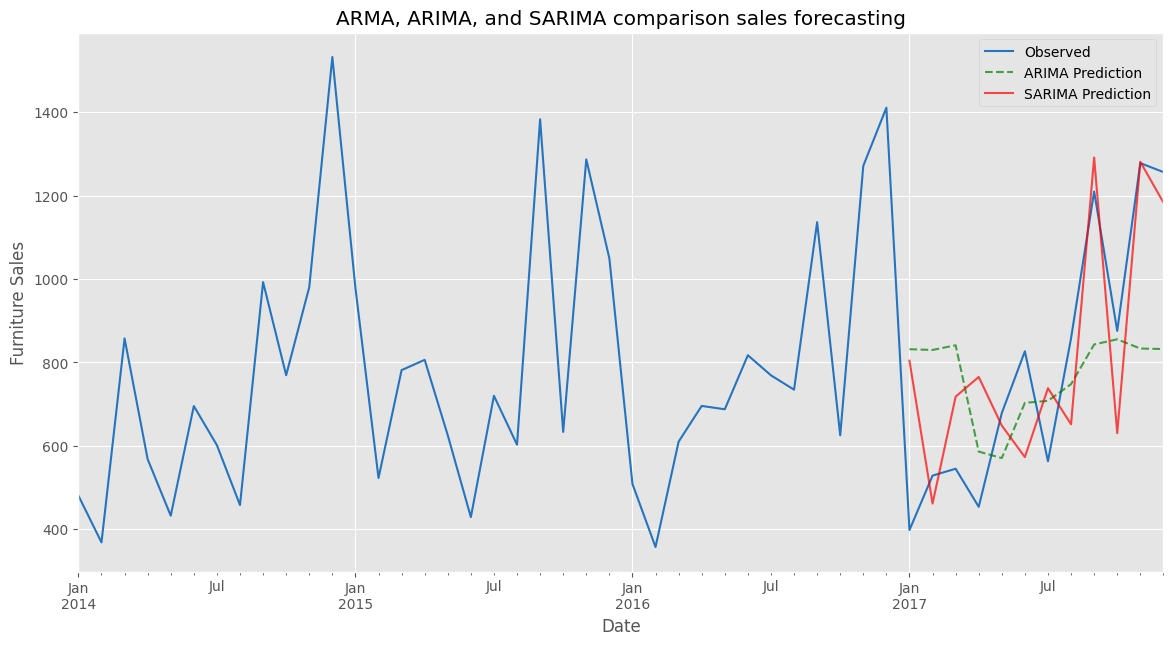

In [47]:
#observed plot
ax = df.plot(label='Observed',color='#2574BF')
#predicted plot
rcParams['figure.figsize'] = 14, 7
arima_predict.plot(ax=ax, label='ARIMA Prediction', linestyle= "--" ,alpha= 0.7, color='g')
sarima_predict_1.predicted_mean.plot(ax=ax, label='SARIMA Prediction', alpha= 0.7, color='red')
plt.title('ARMA, ARIMA, and SARIMA comparison sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

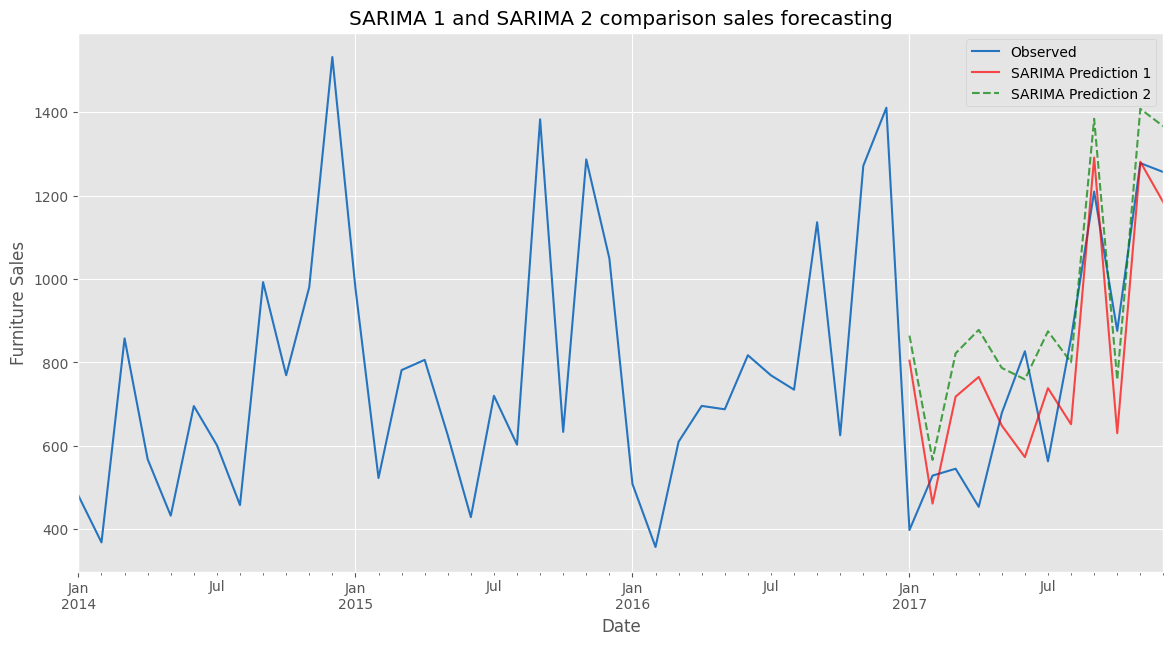

In [48]:
#observed plot
ax = df.plot(label='Observed',color='#2574BF')
#predicted plot
rcParams['figure.figsize'] = 14, 7
sarima_predict_1.predicted_mean.plot(ax=ax, label='SARIMA Prediction 1', alpha= 0.7,linestyle= "-", color='red')
sarima_predict_2.predicted_mean.plot(ax=ax, label='SARIMA Prediction 2', linestyle= "--", alpha= 0.7, color='g')

plt.title('SARIMA 1 and SARIMA 2 comparison sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()


## Double exponential smoothing

In [51]:
warnings.filterwarnings("ignore")
from statsmodels.tsa.holtwinters import ExponentialSmoothing

DES = ExponentialSmoothing(trainset, trend = 'add')
DES_fit = DES.fit(smoothing_level=0.5)
DES_predict = DES_fit.predict(start=pd.to_datetime('2017-01-01'), end=pd.to_datetime('2017-12-01'))

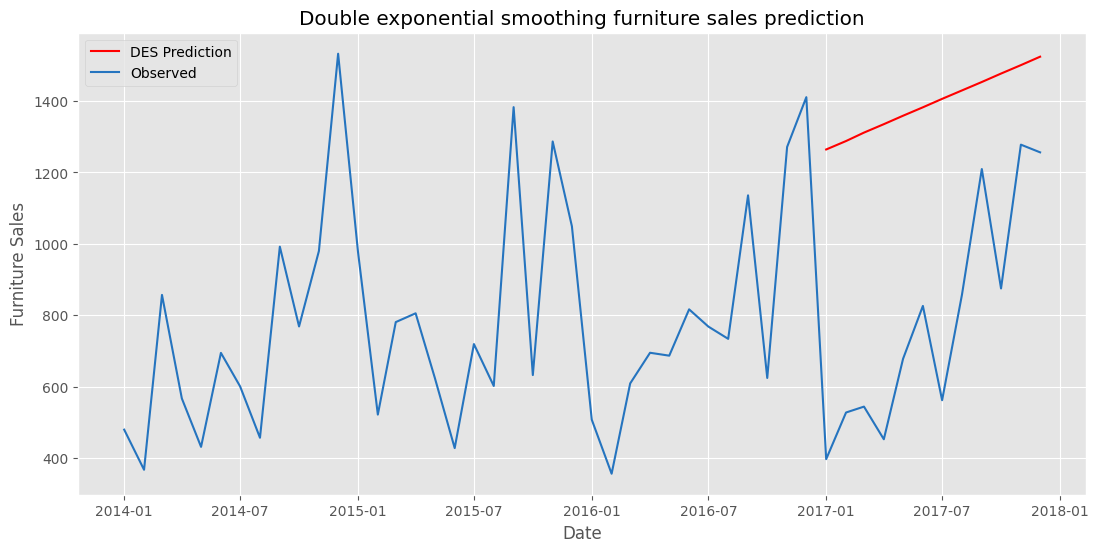

In [52]:
from pylab import rcParams
rcParams['figure.figsize'] = 13, 6
yhat_DES = DES_predict.values.tolist()
y = df.values.tolist()
plt.plot(DES_predict.index, yhat_DES, color='r',label='DES Prediction')
plt.plot(df.index, y, color='#2574BF',label='Observed')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.title('Double exponential smoothing furniture sales prediction')
plt.show()

In [53]:
DES_results=performance(df[-12:], yhat_DES)
DES_results

{'MSE': 420545.71, 'RMSE': 648.49, 'MAPE': 100.74}

### Triple exponential smoothing

In [54]:
#Prediction with exponential smoothing + seasonality
from statsmodels.tsa.holtwinters import ExponentialSmoothing
TES = ExponentialSmoothing(trainset, trend = 'add', seasonal = 'add', seasonal_periods = 12)
TES_fit = TES.fit(smoothing_level=0.5)
TES_predict = TES_fit.predict(start=pd.to_datetime('2017-01-01'), end=pd.to_datetime('2017-12-01'))

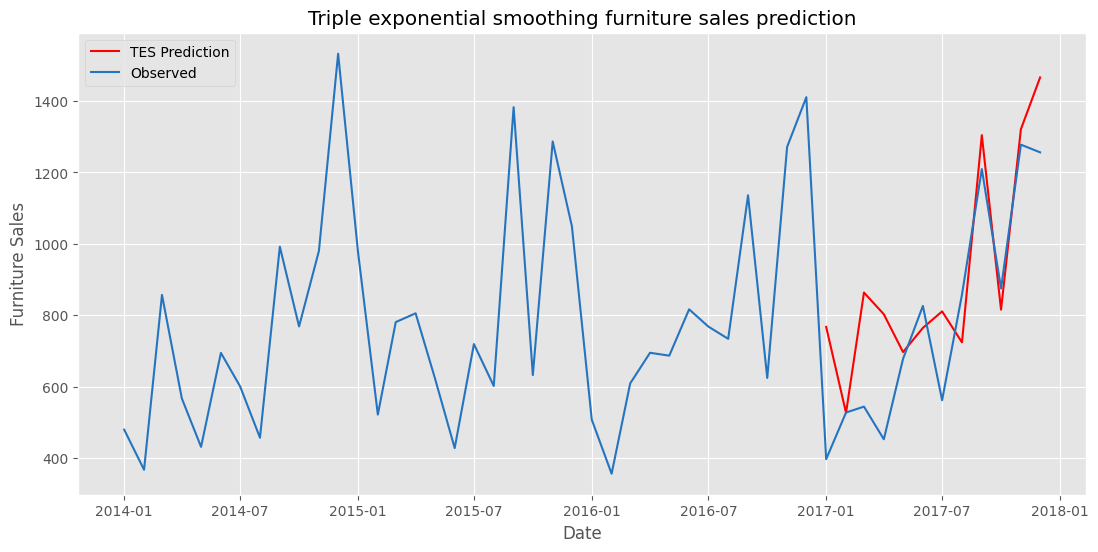

In [55]:
from pylab import rcParams
rcParams['figure.figsize'] = 13, 6
yhat_TES = TES_predict.values.tolist()
y = df.values.tolist()
plt.plot(TES_predict.index, yhat_TES, color='r',label='TES Prediction')
plt.plot(df.index, y, color='#2574BF',label='Observed')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.title('Triple exponential smoothing furniture sales prediction')
plt.show()

In [56]:
TES_results= performance(df[-12:], yhat_TES)
TES_results

{'MSE': 41955.36, 'RMSE': 204.83, 'MAPE': 27.81}

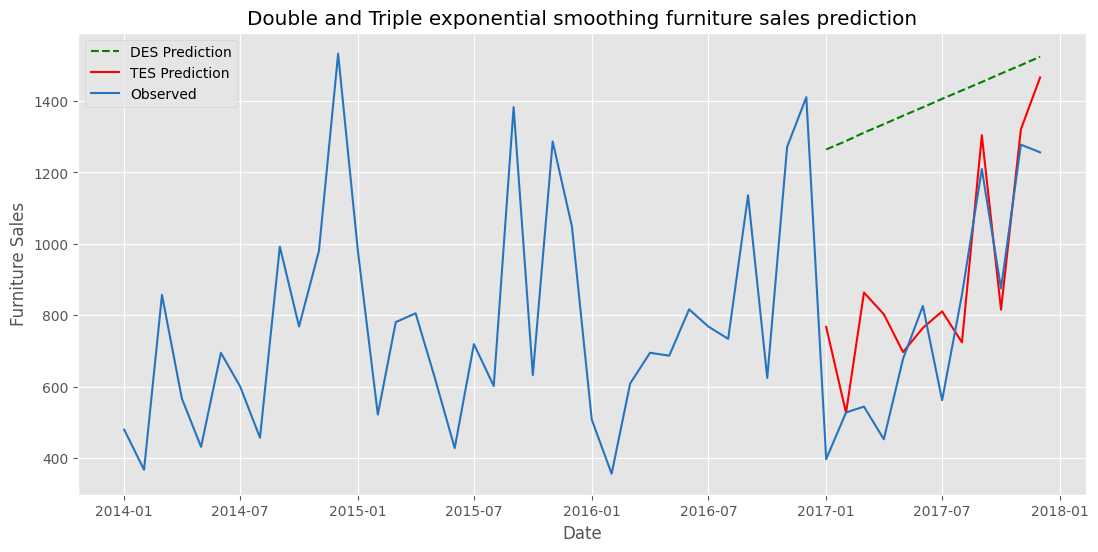

In [57]:
from pylab import rcParams
rcParams['figure.figsize'] = 13, 6
plt.plot(DES_predict.index, yhat_DES, color='g',linestyle= "--",label='DES Prediction')
plt.plot(TES_predict.index, yhat_TES, color='r',label='TES Prediction')
plt.plot(df.index, y, color='#2574BF',label='Observed')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.title('Double and Triple exponential smoothing furniture sales prediction')
plt.show()

## Prophet Method

### Prophet First model

In [58]:
df_furniture_train = pd.DataFrame({'order_date':trainset.index, 'sales':trainset.values})
df_furniture_test = pd.DataFrame({'order_date':testset.index, 'sales':testset.values})

In [61]:
warnings.filterwarnings("ignore")
from prophet import Prophet
df_furniture_train = df_furniture_train.rename(columns={'order_date': 'ds', 'sales': 'y'})
df_furniture_test = df_furniture_test.rename(columns={'order_date': 'ds', 'sales': 'y'})

In [62]:
warnings.filterwarnings("ignore")
# interval_width -> uncertainty interval
furniture_model = Prophet(interval_width=0.95, yearly_seasonality=True)
furniture_model.fit(df_furniture_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8hu02853/9e_td4e2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8hu02853/905hm7g_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87048', 'data', 'file=/tmp/tmp8hu02853/9e_td4e2.json', 'init=/tmp/tmp8hu02853/905hm7g_.json', 'output', 'file=/tmp/tmp8hu02853/prophet_modelpev__jr9/prophet_model-20240527114843.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
11:48:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:48:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [63]:
furniture_forecast = furniture_model.make_future_dataframe(periods=12, freq='MS')
furniture_forecast = furniture_model.predict(furniture_forecast)

<Figure size 1800x600 with 0 Axes>

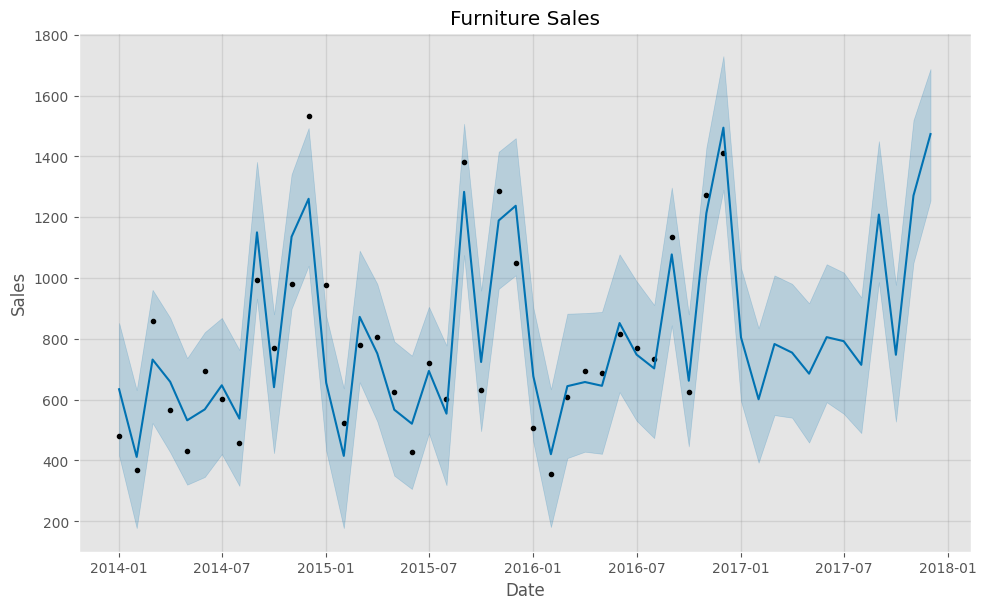

In [64]:
plt.figure(figsize=(18, 6))
furniture_model.plot(furniture_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Furniture Sales')
plt.show()

In [65]:
furniture_forecast.drop(columns=['multiplicative_terms', 'multiplicative_terms_lower','multiplicative_terms_upper'])

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,yhat
0,2014-01-01,681.587747,415.589996,852.198094,681.587747,681.587747,-47.448368,-47.448368,-47.448368,-47.448368,-47.448368,-47.448368,634.139379
1,2014-02-01,685.635861,177.544598,631.344773,685.635861,685.635861,-274.074947,-274.074947,-274.074947,-274.074947,-274.074947,-274.074947,411.560915
2,2014-03-01,689.292223,523.125545,961.023366,689.292223,689.292223,42.431306,42.431306,42.431306,42.431306,42.431306,42.431306,731.723529
3,2014-04-01,693.340337,426.683299,869.224530,693.340337,693.340337,-34.565318,-34.565318,-34.565318,-34.565318,-34.565318,-34.565318,658.775020
4,2014-05-01,697.257867,320.315723,736.433941,697.257867,697.257867,-165.309770,-165.309770,-165.309770,-165.309770,-165.309770,-165.309770,531.948097
5,2014-06-01,701.305982,345.609823,821.650560,701.305982,701.305982,-133.386435,-133.386435,-133.386435,-133.386435,-133.386435,-133.386435,567.919547
6,2014-07-01,705.223512,420.751325,868.599617,705.223512,705.223512,-58.042820,-58.042820,-58.042820,-58.042820,-58.042820,-58.042820,647.180692
7,2014-08-01,709.271626,316.482438,763.244065,709.271626,709.271626,-171.625954,-171.625954,-171.625954,-171.625954,-171.625954,-171.625954,537.645672
8,2014-09-01,713.319740,932.205401,1381.993927,713.319740,713.319740,436.757415,436.757415,436.757415,436.757415,436.757415,436.757415,1150.077155
9,2014-10-01,717.237270,423.697289,880.420218,717.237270,717.237270,-76.341805,-76.341805,-76.341805,-76.341805,-76.341805,-76.341805,640.895465


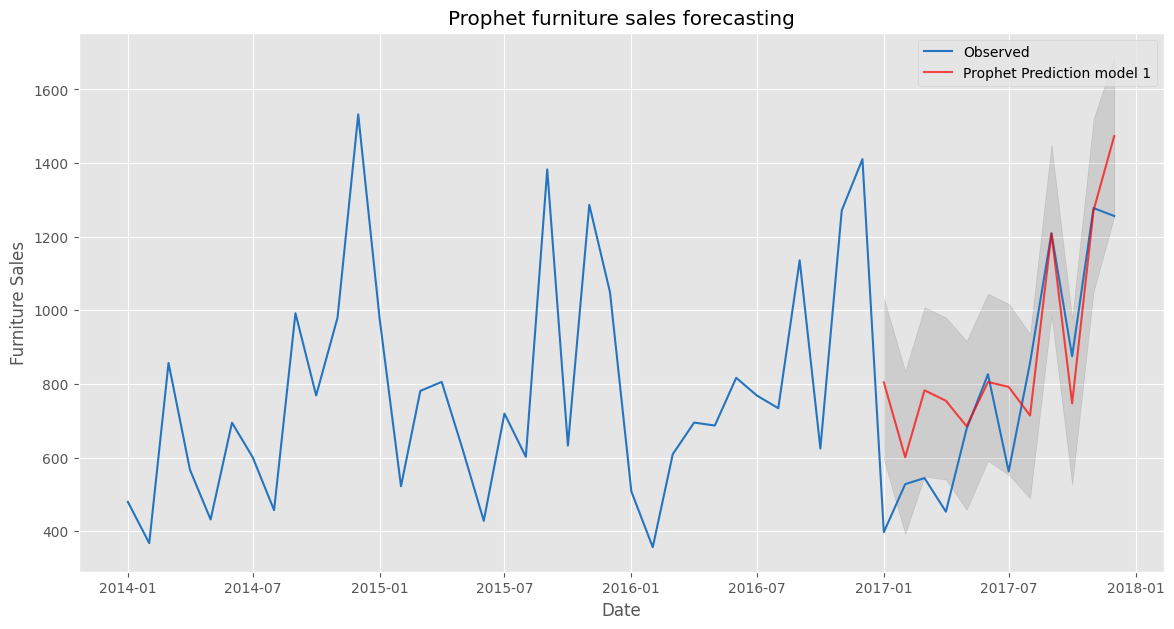

In [66]:
rcParams['figure.figsize'] = 14, 7
plt.plot(df.index, df.values,label='Observed',color='#2574BF')
plt.plot(df[36:48].index,furniture_forecast[36:48]['yhat'].values,label='Prophet Prediction model 1', alpha= 0.7, color='red')
plt.fill_between(df[36:48].index,
                #lower sales
                furniture_forecast[36:48]['yhat_lower'].values,
                #upper sales
                furniture_forecast[36:48]['yhat_upper'].values, color='k', alpha=0.1)
plt.title('Prophet furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [67]:
prophet_results=performance(df[36:48].values, furniture_forecast[36:48]['yhat'])
prophet_results

{'MSE': 37992.43, 'RMSE': 194.92, 'MAPE': 26.67}

In [129]:
test= furniture_forecast.set_index('ds')

### Prophet Second model

In [69]:
#add holidays
new_year_holidays = pd.DataFrame({'holiday': "New Year's Day", 'ds' : pd.to_datetime(['2014-01-01', '2015-01-01','2016-01-01'])})

furniture_model2 = Prophet(yearly_seasonality=True, holidays=new_year_holidays)
furniture_model2.fit(df_furniture_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8hu02853/szv_uki8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8hu02853/j6got5ez.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59875', 'data', 'file=/tmp/tmp8hu02853/szv_uki8.json', 'init=/tmp/tmp8hu02853/j6got5ez.json', 'output', 'file=/tmp/tmp8hu02853/prophet_model6_9pkna9/prophet_model-20240527114912.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
11:49:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:49:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [70]:
furniture_forecast2 = furniture_model2.make_future_dataframe(periods=12, freq='MS')
furniture_forecast2 = furniture_model2.predict(furniture_forecast2)

<Figure size 1800x600 with 0 Axes>

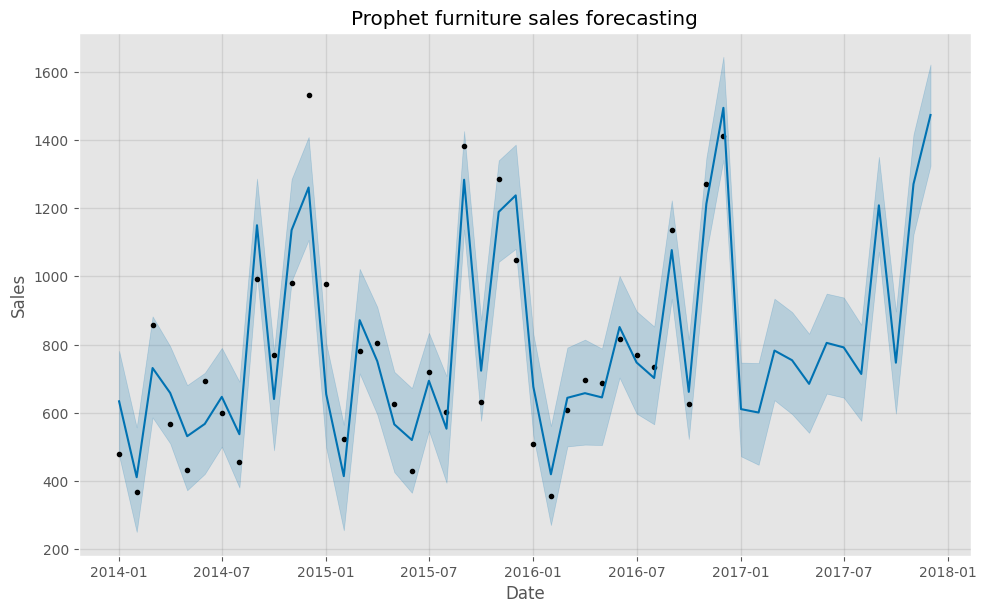

In [71]:
plt.figure(figsize=(18, 6))
furniture_model2.plot(furniture_forecast2, xlabel = 'Date', ylabel = 'Sales')
plt.title('Prophet furniture sales forecasting')
plt.show()

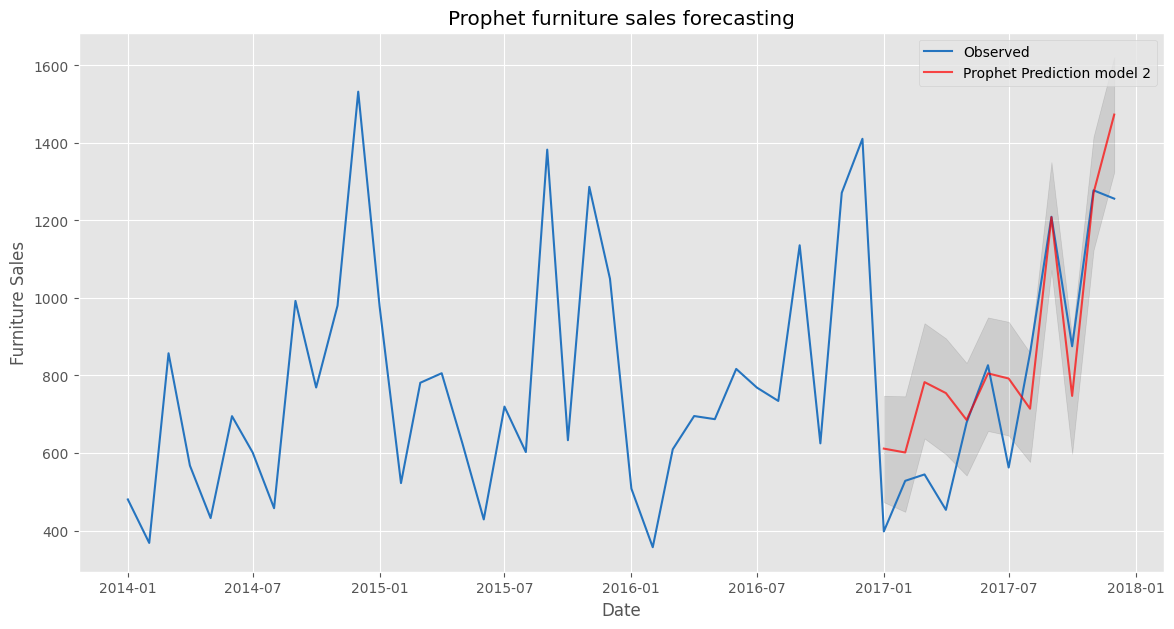

In [72]:
rcParams['figure.figsize'] = 14, 7
plt.plot(df.index, df.values,label='Observed',color='#2574BF')
plt.plot(df[36:48].index,furniture_forecast2[36:48]['yhat'].values,label='Prophet Prediction model 2', alpha= 0.7, color='red')
plt.fill_between(df[36:48].index,
                #lower sales
                furniture_forecast2[36:48]['yhat_lower'].values,
                #upper sales
                furniture_forecast2[36:48]['yhat_upper'].values, color='k', alpha=0.1)
plt.title('Prophet furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [73]:
prophet_results2= performance(df[36:48].values, furniture_forecast2[36:48]['yhat'])
prophet_results

{'MSE': 37992.43, 'RMSE': 194.92, 'MAPE': 26.67}

In [74]:
test2= furniture_forecast2.set_index('ds')

## LSTM

In [75]:
train, test = np.array(df[:-12]), np.array(df[-12:])
train= train.reshape(-1,1)
test= test.reshape(-1,1)

In [76]:
#Scale train and test data to [-1, 1]
scaler = MinMaxScaler()
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

In [77]:
n_input = 12
# univariate
n_features = 1
#TimeseriesGenerator automatically transform a univariate time series dataset into a supervised learning problem.
generator = TimeseriesGenerator(train, train, length=n_input, batch_size=10)

### Vanilla LSTM

In [ ]:
######
#set the counter to repeat
n=20
store= np.zeros((12,n))
for i in range(n):
    model_vanilla = Sequential()
    model_vanilla.add(LSTM(50, activation='relu', input_shape=(12, 1)))
    #Add layer
    model_vanilla.add(Dense(100, activation='relu'))
    model_vanilla.add(Dense(100, activation='relu'))
    #Output
    model_vanilla.add(Dense(1))
    model_vanilla.compile(optimizer='adam', loss='mse')
    # 22
    model_vanilla.fit_generator(generator,epochs=200)

    pred_list = []

    batch = train[-n_input:].reshape((1, n_input, n_features))

    for j in range(n_input):
        pred_list.append(model_vanilla.predict(batch)[0])
        batch = np.append(batch[:,1:,:],[[pred_list[j]]],axis=1)

    df_predict_vanilla = pd.DataFrame(scaler.inverse_transform(pred_list),
                              index=df[-n_input:].index, columns=['Prediction'])


    store[:,i]=df_predict_vanilla['Prediction']
print(store)

Streaming output truncated to the last 5000 lines.
3/3 [==============================] - 0s 11ms/step - loss: 0.0677
Epoch 25/200
3/3 [==============================] - 0s 13ms/step - loss: 0.0679
Epoch 26/200
3/3 [==============================] - 0s 15ms/step - loss: 0.0677
Epoch 27/200
3/3 [==============================] - 0s 17ms/step - loss: 0.0667
Epoch 28/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0660
Epoch 29/200
3/3 [==============================] - 0s 14ms/step - loss: 0.0675
Epoch 30/200
3/3 [==============================] - 0s 10ms/step - loss: 0.0673
Epoch 31/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0665
Epoch 32/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0676
Epoch 33/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0672
Epoch 34/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0667
Epoch 35/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0672
Epoch 

In [85]:
final_vanilla= np.zeros((store.shape[0],1))

#final_vanilla= np.zeros((store.shape[0],1))
for i in range(store.shape[0]):

    final_vanilla[i]=np.mean(store[i,:])
final_vanilla=final_vanilla.reshape((12,))

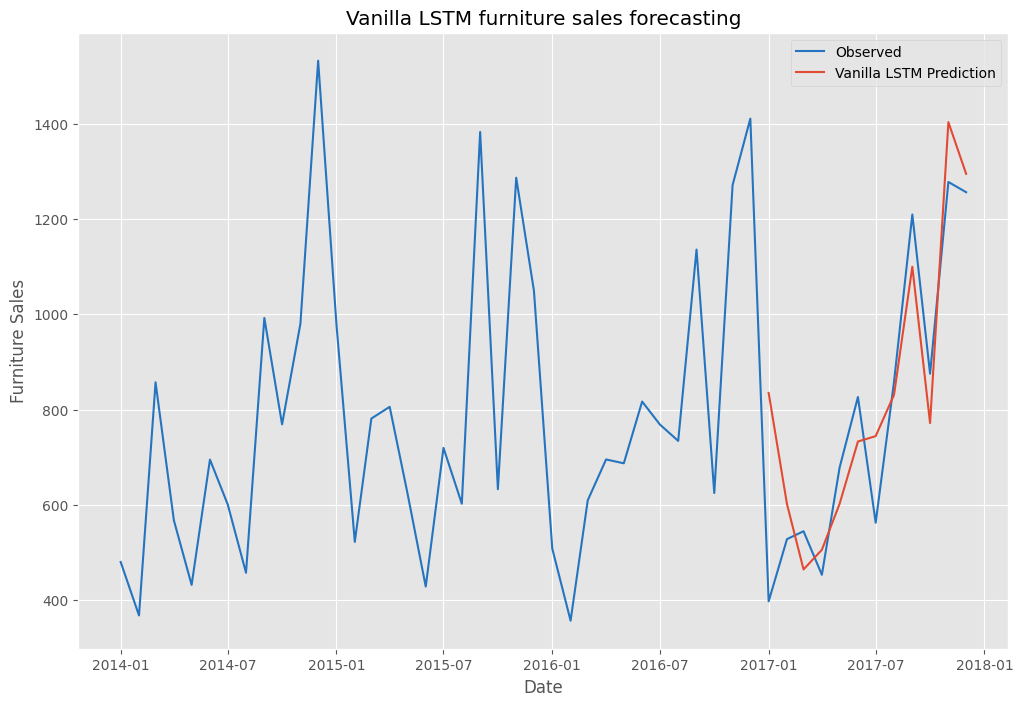

In [86]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,final_vanilla,label="Vanilla LSTM Prediction")
plt.title('Vanilla LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [87]:
final_vanilla= np.zeros((store.shape[0],1))
for i in range(store.shape[0]):

    final_vanilla[i]=np.mean(store[i,:])
final_vanilla=final_vanilla.reshape((12,))


vanilla_lstm= performance(df[-12:],final_vanilla)
vanilla_lstm

{'MSE': 24513.77, 'RMSE': 156.57, 'MAPE': 20.17}

### Stacked LSTM

In [88]:
######
n=20
store2= np.zeros((12,n))
for i in range(n):
    model_stacked = Sequential()
    #In stacked LSTM, we should output a sequence rather than a single value for each input -> return_sequences=True
    model_stacked.add(LSTM(50, activation='relu', return_sequences = True, input_shape=(12, 1)))
    model_stacked.add(LSTM(50, activation='relu'))
    model_stacked.add(Dense(100, activation='relu'))
    model_stacked.add(Dense(50, activation='relu'))
    model_stacked.add(Dense(1))
    model_stacked.compile(optimizer='adam', loss='mse')
    model_stacked.fit_generator(generator,epochs=200)

    pred_list_s = []

    batch = train[-n_input:].reshape((1, n_input, n_features))

    for j in range(n_input):
        pred_list_s.append(model_stacked.predict(batch)[0])
        batch = np.append(batch[:,1:,:],[[pred_list_s[j]]],axis=1)

    df_predict_stacked = pd.DataFrame(scaler.inverse_transform(pred_list_s),
                              index=df[-n_input:].index, columns=['Prediction'])


    store2[:,i]=df_predict_stacked['Prediction']
print(store2)

Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 25ms/step
Epoch 1/200
3/3 [==============================] - 3s 19ms/step - loss: 0.1931
Epoch 2/200
3/3 [==============================] - 0s 16ms/step - loss: 0.1626
Epoch 3/200
3/3 [==============================] - 0s 17ms/step - loss: 0.1314
Epoch 4/200
3/3 [==============================] - 0s 15ms/step - loss: 0.1001
Epoch 5/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0758
Epoch 6/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0714
Epoch 7/200
3/3 [==============================] - 0s 18ms/step - loss: 0.0875
Epoch 8/200
3/3 [==============================] - 0s 15ms/step - loss: 0.0858
Epoch 9/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0760
Epoch 10/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0685
Epoch 11/200
3/3 [==============================] - 0s 15ms/step - loss: 0.0659
Epoch 12/200
3/3 [========

In [93]:
final_stacked2= np.zeros((store2.shape[0],1))
for i in range(store2.shape[0]):

    final_stacked2[i]=np.mean(store2[i,:])
final_stacked2=final_stacked2.reshape((12,))

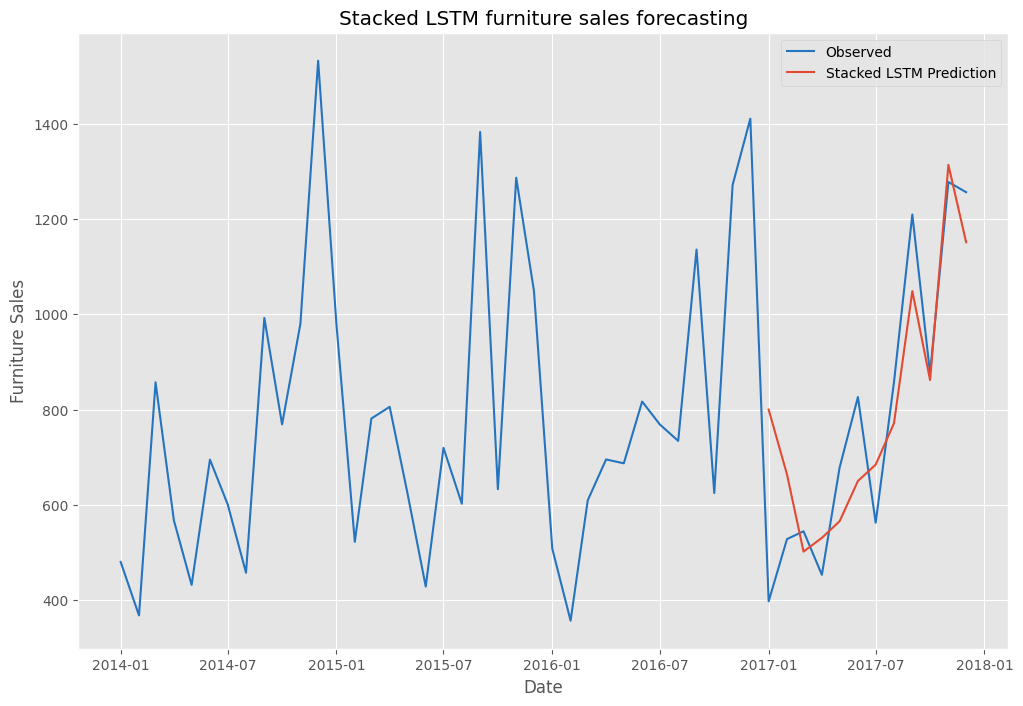

In [94]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,final_stacked2,label="Stacked LSTM Prediction")
plt.title('Stacked LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [95]:
final_stacked2= np.zeros((store2.shape[0],1))
for i in range(store2.shape[0]):

    final_stacked2[i]=np.mean(store2[i,:])
final_stacked2=final_stacked2.reshape((12,))

stacked_lstm= performance(df[-12:],final_stacked2)
stacked_lstm

{'MSE': 24390.18, 'RMSE': 156.17, 'MAPE': 20.63}

### Bidirectional LSTM

In [96]:
# define model
model_bi = Sequential()
model_bi.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(12, 1)))
model_bi.add(Dense(1))
model_bi.compile(optimizer='adam', loss='mse')

In [97]:
model_bi.fit_generator(generator,epochs=200)

Epoch 1/200
3/3 [==============================] - 3s 16ms/step - loss: 0.2149
Epoch 2/200
3/3 [==============================] - 0s 9ms/step - loss: 0.1856
Epoch 3/200
3/3 [==============================] - 0s 8ms/step - loss: 0.1611
Epoch 4/200
3/3 [==============================] - 0s 9ms/step - loss: 0.1377
Epoch 5/200
3/3 [==============================] - 0s 9ms/step - loss: 0.1165
Epoch 6/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0976
Epoch 7/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0808
Epoch 8/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0670
Epoch 9/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0642
Epoch 10/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0724
Epoch 11/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0802
Epoch 12/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0802
Epoch 13/200
3/3 [==============================] - 0s 9ms/s

In [98]:
pred_list_b = []

batch = train[-n_input:].reshape((1, n_input, n_features))

for i in range(n_input):
    pred_list_b.append(model_bi.predict(batch)[0])
    batch = np.append(batch[:,1:,:],[[pred_list_b[i]]],axis=1)

df_predict_bi = pd.DataFrame(scaler.inverse_transform(pred_list_b),
                          index=df[-n_input:].index, columns=['Prediction'])

1/1 [==============================] - 0s 21ms/step


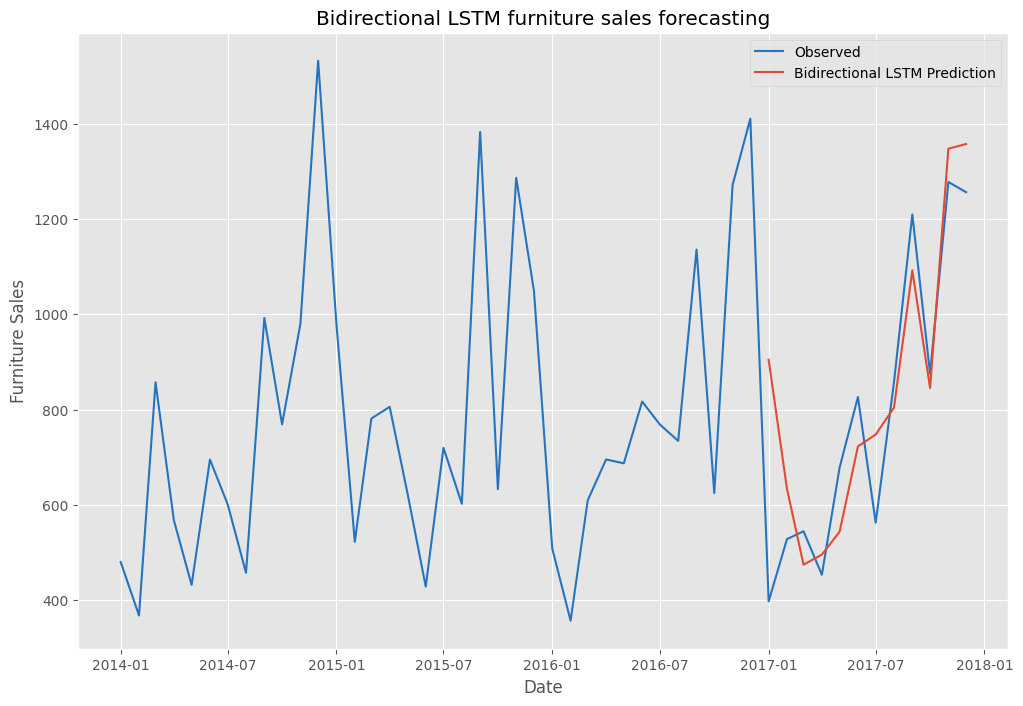

In [99]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,df_predict_bi,label="Bidirectional LSTM Prediction")
plt.title('Bidirectional LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [100]:
bi_lstm= performance(df[-12:],df_predict_bi['Prediction'] )
bi_lstm

{'MSE': 30903.94, 'RMSE': 175.8, 'MAPE': 22.33}

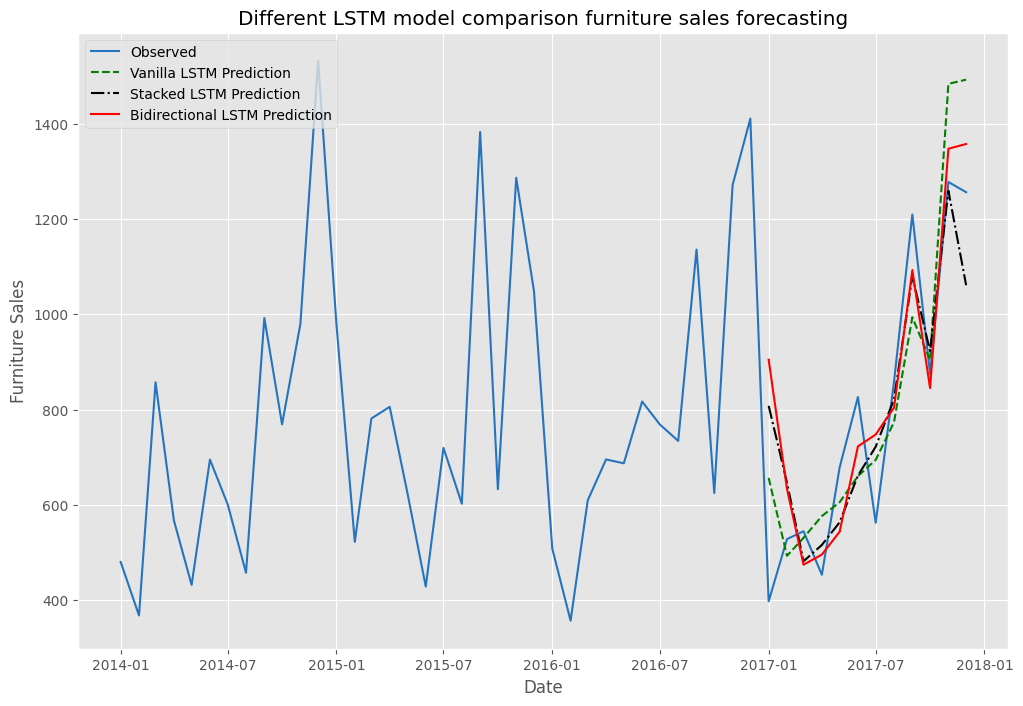

In [101]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
#Vanilla LSTM
plt.plot(df[36:].index,df_predict_vanilla,label="Vanilla LSTM Prediction",linestyle= "--", color='g')
#STacked LSTM
plt.plot(df[36:].index,df_predict_stacked,label="Stacked LSTM Prediction",linestyle= "-.", color="black")
#Bidirectional LSTM
plt.plot(df[36:].index,df_predict_bi,label="Bidirectional LSTM Prediction",marker=',',color='r')
plt.title('Different LSTM model comparison furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend(loc='upper left')
plt.show()

### LSTM model 1

In [102]:
X = df.values

In [103]:
# Transform Time Series to Supervised Learning
def timeseries_to_supervised(data, lag=1):
    df = DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df
# Make a differenced series to make time-series stationary
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return Series(diff)

# invert differenced value
def inverse_difference(history, yhat, interval=1):
    return yhat + history[-interval]

In [104]:
# Transform Time Series to Stationary
raw_values = df.values
diff_values = difference(raw_values, 1)

In [105]:
# Transform Time Series to Supervised Learning
supervised = timeseries_to_supervised(diff_values, 1)
supervised_values = supervised.values

In [106]:
train_size = int(len(df) * 0.75)
trainset, testset= supervised_values[0:-12], supervised_values[-12:]

In [107]:
# Scale train and test data to [-1, 1]
def scale(train, test):
    # fit scaler
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler = scaler.fit(train)
    # transform train
    train = train.reshape(train.shape[0], train.shape[1])
    train_scaled = scaler.transform(train)
    # transform test
    test = test.reshape(test.shape[0], test.shape[1])
    test_scaled = scaler.transform(test)
    return scaler, train_scaled, test_scaled

In [108]:
#  Invert the scale on forecasts to the original scale
def invert_scale(scaler, X, value):
    new_row = [x for x in X] + [value]
    array = np.array(new_row)
    array = array.reshape(1, len(array))
    inverted = scaler.inverse_transform(array)
    return inverted[0, -1]

In [109]:
# transform the scale of the data
scaler, train_scaled, test_scaled = scale(trainset, testset)

In [110]:
# fit an LSTM network to train the data
def fit_lstm(train, batch_size, nb_epoch, neurons):
    X, y = train[:, 0:-1], train[:, -1]
    X = X.reshape(X.shape[0], 1, X.shape[1])
    model = Sequential()
    model.add(LSTM(neurons, batch_input_shape=(batch_size, X.shape[1], X.shape[2]), stateful=True))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    for i in range(nb_epoch):
        #epoch can be changed to 1
        model.fit(X, y, epochs=5, batch_size=batch_size, verbose=1, shuffle=False)
        model.reset_states()
    return model

In [111]:
# fit the model
lstm_model = fit_lstm(train_scaled, 1, 100, 4)
# forecast the entire training dataset to build up state for forecasting
train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
lstm_model.predict(train_reshaped, batch_size=1)

Epoch 1/5
35/35 [==============================] - 2s 2ms/step - loss: 0.2697
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2647
Epoch 3/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2609
Epoch 4/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2575
Epoch 5/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2543
Epoch 1/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2511
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2484
Epoch 3/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2455
Epoch 4/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2426
Epoch 5/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2398
Epoch 1/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2371
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2345
Epoch 3/5
35/35 [==============================] - 0s 2ms/step -

array([[-0.07605886],
       [ 0.03192814],
       [-0.3738386 ],
       [-0.12574795],
       [ 0.01575481],
       [-0.17811859],
       [-0.03270643],
       [ 0.12960339],
       [-0.37796065],
       [-0.07408754],
       [-0.22111005],
       [-0.66453564],
       [-0.20131207],
       [ 0.16387922],
       [-0.06604741],
       [-0.00705186],
       [ 0.21404105],
       [ 0.38076824],
       [ 0.01597152],
       [ 0.24384844],
       [-0.60222936],
       [ 0.13840514],
       [-0.53537107],
       [-0.23578745],
       [ 0.24093777],
       [ 0.32729822],
       [ 0.04176543],
       [ 0.04196235],
       [ 0.12137338],
       [ 0.02638403],
       [ 0.15589806],
       [ 0.2174626 ],
       [-0.2101073 ],
       [ 0.41267034],
       [-0.39739352]], dtype=float32)

In [112]:
# make a one-step forecast
def forecast_lstm(model, batch_size, X):
    X = X.reshape(1, 1, len(X))
    yhat = model.predict(X, batch_size=batch_size)
    return yhat[0,0]

In [113]:
# walk-forward validation on the test data
predictions_lstm1 = list()
for i in range(len(test_scaled)):
    # make one-step forecast
    X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
    yhat = forecast_lstm(lstm_model, 1, X)
    # invert scaling
    yhat = invert_scale(scaler, X, yhat)
    # invert differencing
    yhat = inverse_difference(raw_values, yhat, len(test_scaled)+1-i)
    # store forecast
    predictions_lstm1.append(yhat)
    expected = raw_values[len(train_scaled) + i ]
    print('Month=%d, Predicted=%f, Expected=%f' % (i+1, yhat, expected))

1/1 [==============================] - 0s 19ms/step
Month=1, Predicted=1123.985839, Expected=1410.719808
1/1 [==============================] - 0s 21ms/step
Month=2, Predicted=761.375248, Expected=397.602133
1/1 [==============================] - 0s 17ms/step
Month=3, Predicted=699.351007, Expected=528.179800
1/1 [==============================] - 0s 17ms/step
Month=4, Predicted=728.689159, Expected=544.672240
1/1 [==============================] - 0s 18ms/step
Month=5, Predicted=729.031118, Expected=453.297905
1/1 [==============================] - 0s 18ms/step
Month=6, Predicted=746.610333, Expected=678.302328
1/1 [==============================] - 0s 17ms/step
Month=7, Predicted=843.220296, Expected=826.460291
1/1 [==============================] - 0s 17ms/step
Month=8, Predicted=855.473981, Expected=562.524857
1/1 [==============================] - 0s 17ms/step
Month=9, Predicted=857.056573, Expected=857.881889
1/1 [==============================] - 0s 18ms/step
Month=10, Predicted

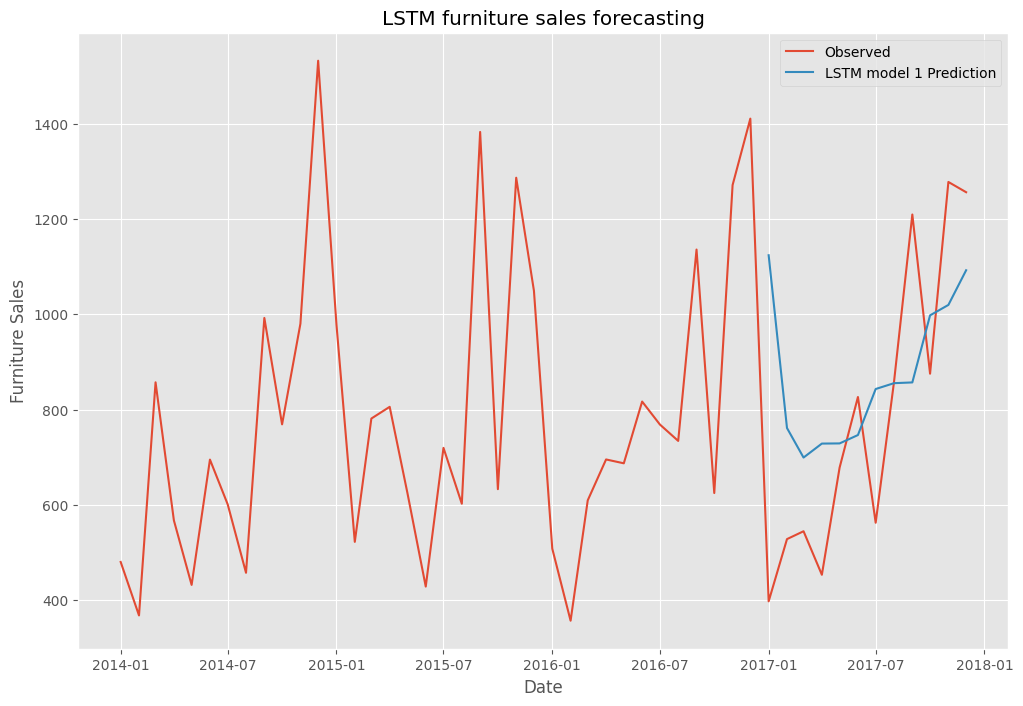

In [114]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed")
plt.plot(df[36:].index,predictions_lstm1,label="LSTM model 1 Prediction")
plt.title('LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [115]:
lstm1= performance(raw_values[-12:], predictions_lstm1)
lstm1

{'MSE': 83516.44, 'RMSE': 288.99, 'MAPE': 38.31}

### Convolutional Neural Network

In [116]:
dfcnn= np.array(df)
dfcnn= dfcnn.reshape(-1,1)
#Scale data
scaler = MinMaxScaler()
ts = scaler.fit_transform(dfcnn)

In [117]:
#Set the timestep
timestep = 12
X= []
Y=[]
raw_data=ts
for i in range(len(raw_data)- (timestep)):
    X.append(raw_data[i:i+timestep])
    Y.append(raw_data[i+timestep])


X=np.asanyarray(X)
Y=np.asanyarray(Y)
#Set the trainset
X_train = X[:24,:,:]
Y_train = Y[:24]
#Set the testset
X_test = X[24:,:,:]
Y_test= Y[24:]

In [118]:
#define model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu', input_shape=(12, 1)))
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu'))
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(100, activation='relu'))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')


# fit model
cnn_model.fit(X_train, Y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 [==============================] - 1s 1s/step - loss: 0.2089
Epoch 2/200
1/1 [==============================] - 0s 19ms/step - loss: 0.1538
Epoch 3/200
1/1 [==============================] - 0s 21ms/step - loss: 0.1131
Epoch 4/200
1/1 [==============================] - 0s 13ms/step - loss: 0.0824
Epoch 5/200
1/1 [==============================] - 0s 16ms/step - loss: 0.0748
Epoch 6/200
1/1 [==============================] - 0s 20ms/step - loss: 0.0901
Epoch 7/200
1/1 [==============================] - 0s 14ms/step - loss: 0.0919
Epoch 8/200
1/1 [==============================] - 0s 17ms/step - loss: 0.0802
Epoch 9/200
1/1 [==============================] - 0s 15ms/step - loss: 0.0695
Epoch 10/200
1/1 [==============================] - 0s 14ms/step - loss: 0.0655
Epoch 11/200
1/1 [==============================] - 0s 14ms/step - loss: 0.0662
Epoch 12/200
1/1 [==============================] - 0s 13ms/step - loss: 0.0679
Epoch 13/200
1/1 [==============================] -

In [119]:
# Validate data
preds = cnn_model.predict(X_test)
preds=np.array(preds)
preds=preds.reshape(-1,1)
preds = scaler.inverse_transform(preds)


Y_test=np.asanyarray(Y_test)
Y_test=Y_test.reshape(-1,1)
Y_test = scaler.inverse_transform(Y_test)


Y_train=np.asanyarray(Y_train)
Y_train=Y_train.reshape(-1,1)
Y_train = scaler.inverse_transform(Y_train)


1/1 [==============================] - 0s 102ms/step


In [121]:
cnn= performance(Y_test,preds)
cnn_predict= preds.reshape((12,))
cnn

{'MSE': 41829.36, 'RMSE': 204.52, 'MAPE': 22.81}

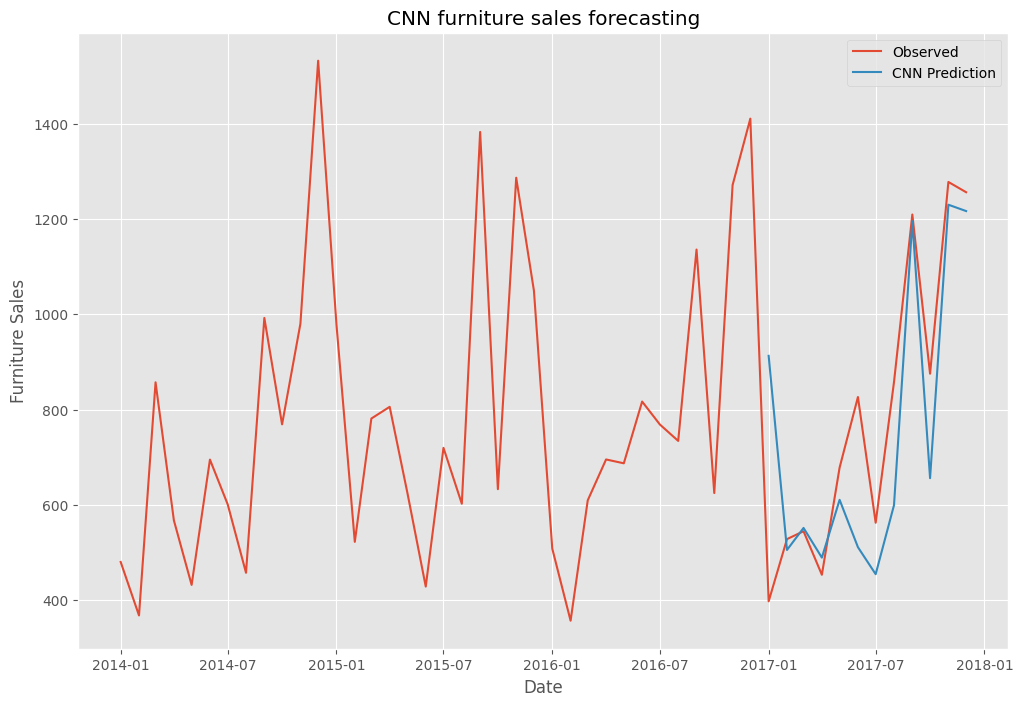

In [122]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed")
plt.plot(df[36:].index,preds,label="CNN Prediction")
plt.title('CNN furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

## Results:

In [123]:
# intialise data of lists.
prediction_data = {'Model':['ARIMA','SARIMA 1','SARIMA 2','DES','TES','Prophet1','Prophet2',
                           'Vanilla LSTM','Stacked LSTM','Bidirectional LSTM','LSTM 1','CNN'],

                    'MSE':[arima_results['MSE'],sarima_results['MSE'],sarima_results2['MSE'],
                           DES_results['MSE'],TES_results['MSE'],prophet_results['MSE'],prophet_results2['MSE'],
                           vanilla_lstm['MSE'],stacked_lstm['MSE'],bi_lstm['MSE'],lstm1['MSE'],cnn['MSE']
                          ],
                  'RMSE':[arima_results['RMSE'],sarima_results['RMSE'],sarima_results2['RMSE'],
                          DES_results['RMSE'],TES_results['RMSE'],prophet_results['RMSE'],prophet_results2['RMSE'],
                          vanilla_lstm['RMSE'],stacked_lstm['RMSE'],bi_lstm['RMSE'],lstm1['RMSE'],cnn['RMSE']
                         ],
                  'MAPE':[arima_results['MAPE'],sarima_results['MAPE'],sarima_results2['MAPE'],
                          DES_results['MAPE'],TES_results['MAPE'],prophet_results['MAPE'],prophet_results2['MAPE'],
                          vanilla_lstm['MAPE'],stacked_lstm['MAPE'],bi_lstm['MAPE'],lstm1['MAPE'],cnn['MAPE']
                         ]}

# Create DataFrame
prediction_table = pd.DataFrame(prediction_data)
prediction_table

,Model,MSE,RMSE,MAPE
0,ARIMA,79779.20,282.45,35.04
1,SARIMA 1,42305.37,205.68,28.89
2,SARIMA 2,55497.86,235.58,33.50
3,DES,420545.71,648.49,100.74
4,TES,41955.36,204.83,27.81
5,Prophet1,37992.43,194.92,26.67
6,Prophet2,27986.69,167.29,22.62
7,Vanilla LSTM,24513.77,156.57,20.17
8,Stacked LSTM,24390.18,156.17,20.63
9,Bidirectional LSTM,30903.94,175.80,22.33


In [130]:
# intialise data of lists.
prediction_data = {
        'Test Set':df[-12:],
        'ARIMA':arima_predict,
        'SARIMA':sarima_predict_1.predicted_mean,
        'DES':yhat_DES,
        'TES':yhat_TES,
        'Prophet1':test['2017-01-01':'2017-12-01']['yhat'],
        'Prophet2':test2['2017-01-01':'2017-12-01']['yhat']}

# Create DataFrame
prediction_table = pd.DataFrame(prediction_data)
prediction_table

,Test Set,ARIMA,SARIMA,DES,TES,Prophet1,Prophet2
2017-01-01,397.602133,831.385306,803.994588,1264.321387,767.765819,804.654419,611.317264
2017-02-01,528.179800,829.595977,461.016739,1287.926358,527.251522,601.207371,601.273672
2017-03-01,544.672240,840.857132,717.583256,1311.531329,863.932442,782.903869,782.875321
2017-04-01,453.297905,585.827299,764.867261,1335.136300,803.176381,754.584495,754.558841
2017-05-01,678.302328,570.203570,648.086385,1358.741271,697.294935,685.354020,685.313846
2017-06-01,826.460291,702.834480,572.567132,1382.346242,765.005861,805.507165,805.413754
2017-07-01,562.524857,707.430821,737.887081,1405.951213,811.254225,792.293340,792.176215
2017-08-01,857.881889,747.601132,651.320055,1429.556183,724.534912,714.448468,714.293983
2017-09-01,1209.508583,842.811958,1291.261366,1453.161154,1304.412092,1208.613662,1208.429315
2017-10-01,875.362728,855.146867,629.973778,1476.766125,816.024284,747.520330,747.343553


In [131]:
# intialise data of lists.
prediction_data2 = {
        'Test Set':df[-12:],
        'Vanilla LSTM':df_predict_vanilla['Prediction'],
        'Stacked LSTM':df_predict_stacked['Prediction'],
        'Bidirectional LSTM':df_predict_bi['Prediction'],
        'LSTM model 1': predictions_lstm1,
        'CNN': cnn_predict}

# Create DataFrame
prediction_table2 = pd.DataFrame(prediction_data2)
prediction_table2

,Test Set,Vanilla LSTM,Stacked LSTM,Bidirectional LSTM,LSTM model 1,CNN
order_date,,,,,,
2017-01-01,397.602133,656.655616,807.964627,904.755916,1123.985839,912.873901
2017-02-01,528.179800,493.176950,646.655236,633.596077,761.375248,505.383118
2017-03-01,544.672240,530.868460,481.702029,474.423076,699.351007,551.622009
2017-04-01,453.297905,576.499791,515.895791,495.736413,728.689159,489.323181
2017-05-01,678.302328,605.453465,563.403464,543.550410,729.031118,610.604004
2017-06-01,826.460291,660.406862,661.481635,722.766102,746.610333,511.219666
2017-07-01,562.524857,694.316710,721.990736,747.674116,843.220296,454.539581
2017-08-01,857.881889,773.593287,821.743402,804.120480,855.473981,599.391113
2017-09-01,1209.508583,993.797292,1079.873927,1092.480300,857.056573,1195.242798


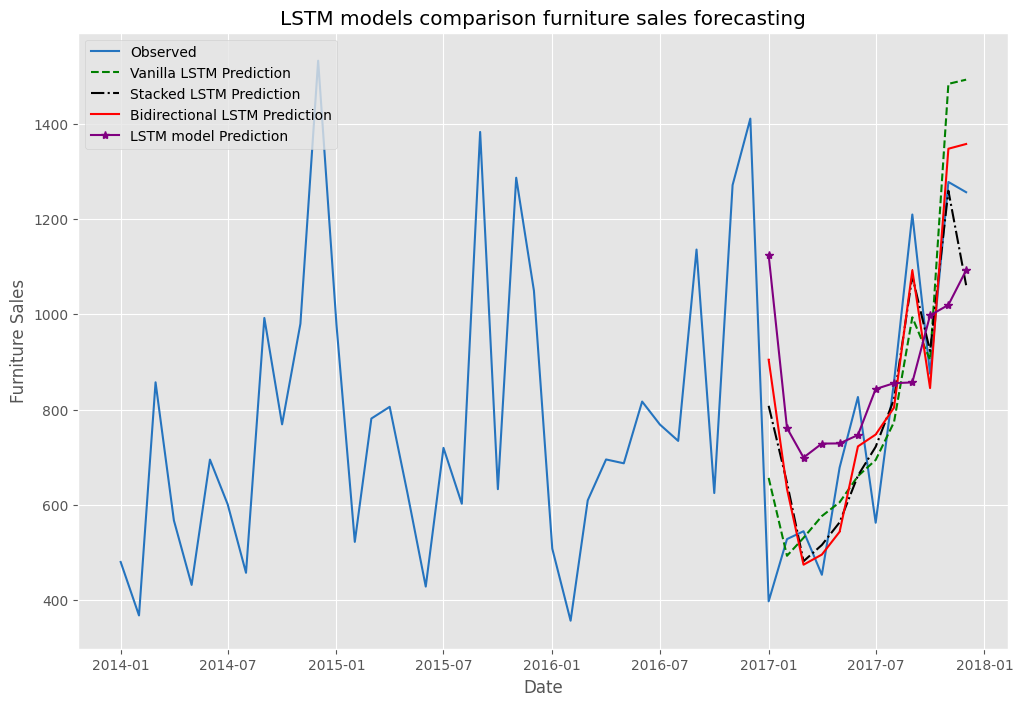

In [138]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
#Vanilla LSTM
plt.plot(df[36:].index,df_predict_vanilla,label="Vanilla LSTM Prediction",linestyle= "--", color='g')
#STacked LSTM
plt.plot(df[36:].index,df_predict_stacked,label="Stacked LSTM Prediction",linestyle= "-.", color="black")
#Bidirectional LSTM
plt.plot(df[36:].index,df_predict_bi,label="Bidirectional LSTM Prediction",marker=',',color='r')
#LSTM model
plt.plot(df[36:].index,predictions_lstm1,label="LSTM model Prediction",marker="*",color="purple")
plt.title('LSTM models comparison furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend(loc='upper left')
plt.show()

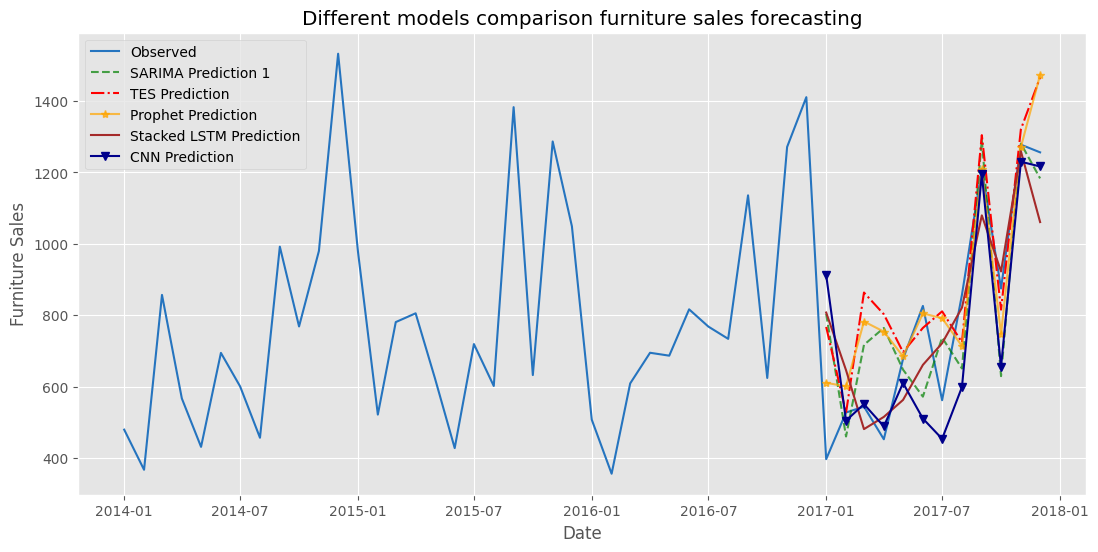

In [140]:
from pylab import rcParams
rcParams['figure.figsize'] = 13, 6
#observed plot
plt.plot(df.index, df, color='#2574BF',label='Observed')
#SARIMA
plt.plot(sarima_predict_1.predicted_mean, label='SARIMA Prediction 1', alpha= 0.7,linestyle= "--", color='g')
#TES
yhat_TES = TES_predict.values.tolist()
y = df.values.tolist()
plt.plot(TES_predict.index, yhat_TES, color='r',label='TES Prediction',linestyle= "-.")
#Prophet 2
plt.plot(df[36:48].index,furniture_forecast2[36:48]['yhat'].values,label='Prophet Prediction', alpha= 0.7, color='Orange',marker= "*")
#Stacked LSTM
plt.plot(df[36:].index,df_predict_stacked,label="Stacked LSTM Prediction",linestyle= "solid", color='brown')
#CNN
plt.plot(df[36:].index,preds,label="CNN Prediction",marker='v',color='darkblue')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.title('Different models comparison furniture sales forecasting')
plt.show()

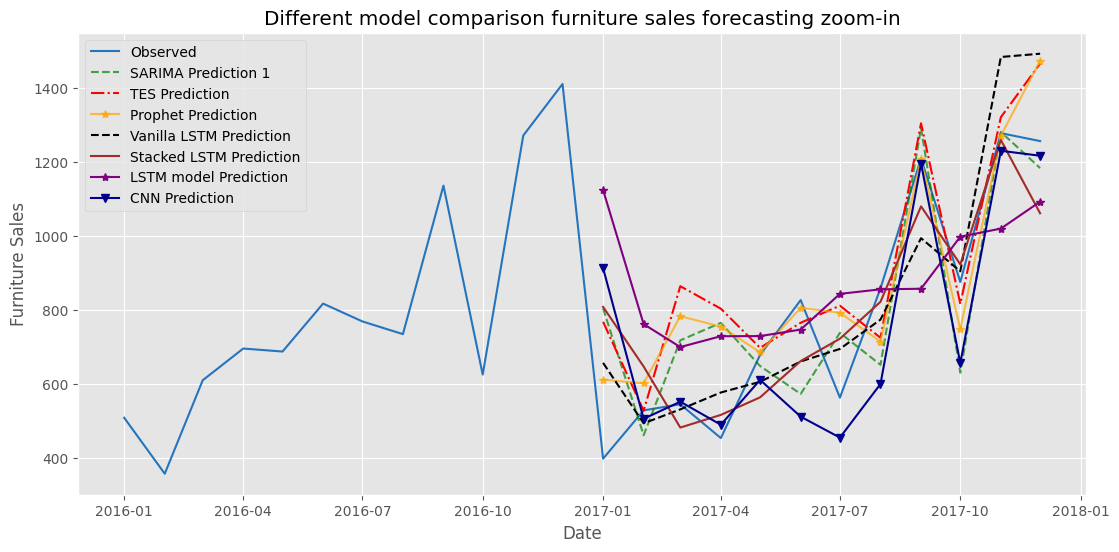

In [141]:
from pylab import rcParams
rcParams['figure.figsize'] = 13, 6
#observed plot
plt.plot(df[24:].index, df[24:], color='#2574BF',label='Observed')
#SARIMA
plt.plot(sarima_predict_1.predicted_mean, label='SARIMA Prediction 1', alpha= 0.7,linestyle= "--", color='g')
#TES
yhat_TES = TES_predict.values.tolist()
y = df.values.tolist()
plt.plot(TES_predict.index, yhat_TES, color='r',label='TES Prediction',linestyle= "-.")
#Prophet 2
plt.plot(df[36:48].index,furniture_forecast2[36:48]['yhat'].values,label='Prophet Prediction', alpha= 0.7, color='Orange',marker= "*")
#Vanilla LSTM
plt.plot(df[36:].index,df_predict_vanilla,label="Vanilla LSTM Prediction",linestyle= "--", color='black')
#Stacked LSTM
plt.plot(df[36:].index,df_predict_stacked,label="Stacked LSTM Prediction",linestyle= "solid", color='brown')
#LSTM model 2
plt.plot(df[36:].index,predictions_lstm1,label="LSTM model Prediction",marker="*",color="purple")
#CNN
plt.plot(df[36:].index,preds,label="CNN Prediction",marker='v',color='darkblue')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.title('Different model comparison furniture sales forecasting zoom-in')
plt.show()